# 2024 Spoken Wiki attentional word recognition task results

### Analysis is for main diotic experiment
### Models run on all combinations of stimuli
___

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle
import importlib 
import IPython.display as ipd
%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter

import src.util_process_prolific as up 
importlib.reload(up)


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


<module 'src.util_process_prolific' from '/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/util_process_prolific.py'>

In [2]:
outfig_dest = Path('CCN_2024/figures')
outfig_dest.mkdir(parents=True, exist_ok=True)





### Import human data

In [3]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
path_to_expmt_stim = Path("/om/user/imgriff/datasets/human_azim_spotlight_SWC_2024/")
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("azimuth_spotlight_experiment/data/*.json"))

len(human_fnames)

920

## Process Human Results

In [4]:
## Get all subject data into one df for analysis

dfs = []
for fname in human_fnames:
    try:
        dfs.append(up.get_part_df_swc(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]
results_df = results_df[results_df.itd_passed == True]
results_df = results_df[results_df.hearing_loss == False]
results_df = results_df[results_df.id_version >= 1]
# results_df = results_df[results_df.over_ear_hf == True]


## Add snr and condition names as columns - unpack from file code in file names 

# get cond name map
map_path = path_to_expmt_stim / 'human_azim_spotlight_cond_map.pkl' 
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)
stim_cond_map = {f"condition_{k:02}": (v['target_azim'], v['dist_azim_delta'], v['distractor_azim']) for k,v in stim_cond_map.items()}

# add as columns 
results_df['condition'], results_df['target_azim'], results_df['dist_azim_delta'], results_df['distractor_azim'] = zip(*results_df['stimulus'].apply(lambda x: up.get_stim_target_azim_and_dist_detla(x, stim_cond_map=stim_cond_map)))

# # remap azimuths to be in the range -180 to 180 for plotting 
remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 
remap_azim = np.vectorize(remap_azim)
results_df['target_azim'] = remap_azim(results_df['target_azim'])
results_df['distractor_azim'] = remap_azim(results_df['distractor_azim'])
results_df['dist_azim_delta'] = remap_azim(results_df['dist_azim_delta'])


# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str].copy()

# trial_results['condition'] = trial_results['raw_condition'].replace(condition_map)

# screen based on completion 
total_trials = 96
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').condition.count() >= total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]
# Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')

# add shortened stim name field 
trial_results['stim_name'] = trial_results['stimulus'].str.split('/').str[-1].str.split('.').str[0]

# drop coluns in trial_results that are all nans 
trial_results = trial_results.dropna(axis=1, how='all')

Unterminated string starting at: line 1 column 167210 (char 167209)
/mindhive/mcdermott/www/imgriff/msjspsych/azimuth_spotlight_experiment/data/subj_642f3188cc01a6b87e28a081.json
Unterminated string starting at: line 1 column 119351 (char 119350)
/mindhive/mcdermott/www/imgriff/msjspsych/azimuth_spotlight_experiment/data/subj_5f105b47d36c8701ec112317.json
Unterminated string starting at: line 1 column 59677 (char 59676)
/mindhive/mcdermott/www/imgriff/msjspsych/azimuth_spotlight_experiment/data/subj_647003e9da103f564525356f.json
Unterminated string starting at: line 1 column 179134 (char 179133)
/mindhive/mcdermott/www/imgriff/msjspsych/azimuth_spotlight_experiment/data/subj_6684b71a5615b7da8e59ce56.json
Expecting value: line 1 column 191136 (char 191135)
/mindhive/mcdermott/www/imgriff/msjspsych/azimuth_spotlight_experiment/data/subj_667428a9835845b07ddb4a02.json
Unterminated string starting at: line 1 column 167150 (char 167149)
/mindhive/mcdermott/www/imgriff/msjspsych/azimuth_spotl

In [5]:
# trial_results = trial_results[trial_results.target_azim != - 90]

In [6]:
# catch_trial_particiapnt_performance
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()

print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 11/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response.isna())]
analysis_df = analysis_df.dropna(axis=1, how='all').dropna(axis=0, how='all')
# analysis_df.groupby('id_subject').condition.count()

N total participants  255
N good participants  239



#### Add re-scored performance based on entries included in excerpt transcripts  

In [7]:
### Make map from cv dictionary ixs to experiment word ixs 

## import cv maps
import pickle
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


## import experiment word map
human_exp_word_key = pickle.load( open(path_to_expmt_stim / "human_azim_spotlight_word_key.pkl", "rb" )) 
exp_word_2_class = {v:k for k,v in human_exp_word_key.items()}



In [8]:
## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str

manifests = pd.read_pickle(path_to_expmt_stim / "human_azim_spotlight_stim_manifest.pdpkl")
# add columns for word int and stim name to map back to participant data 
manifests['word_fname_int'] = manifests['word'].replace(exp_word_2_class)
manifests['stim_name'] = manifests[['gender', 'word_fname_int']].apply(lambda row: f"{row.gender[0]}_{row.word_fname_int:03d}", axis=1)

cols_to_merge = ['stim_name',
                 'word',
                 'target_transcripts',
                 'distractor_transcripts',
                 'distractor_word',

]

analysis_df = pd.merge(analysis_df,
                        manifests[cols_to_merge],
                                    left_on='stim_name', right_on='stim_name', how='left')
analysis_df['confusions'] = (analysis_df.response == analysis_df.distractor_word).astype('int')
analysis_df['accuracy'] = (analysis_df.response == analysis_df.word).astype('int')


# add adjusted accuracy and confusions 
pred_words = analysis_df.response.values
target_words = analysis_df.word.values
target_transcripts = analysis_df.target_transcripts.values
distractor_words = analysis_df.distractor_word.values
distractor_transcripts = analysis_df.distractor_transcripts.values


adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                            if not isinstance(target_transcript, float) else np.nan
                            for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                            ])

adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == dist_word)
                            if not (isinstance(distractor_transcript, float)) else np.nan
                            for pred_word, dist_word, distractor_transcript in zip(pred_words, distractor_words,  distractor_transcripts)
                            ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs

analysis_df = analysis_df[analysis_df.condition != 'catch_trial']


In [9]:
to_check = analysis_df[analysis_df.condition!="catch_trial"]
(to_check.adjusted_accuracy >= to_check.accuracy).all()

True

In [10]:
analysis_df.condition.unique()

array(['spatialized'], dtype=object)

In [11]:
analysis_df.columns

Index(['trial_type', 'trial_index', 'time_elapsed', 'internal_node_id',
       'output_filename', 'id_random', 'id_study', 'id_subject', 'id_session',
       'id_version', 'hc_passed', 'itd_passed', 'rt', 'response', 'stimulus',
       'response_str', 'catch_trial', 'correct_response', 'trial_num',
       'correct', 'n_correct', 'n_incorrect', 'over_ear_hf', 'hearing_loss',
       'condition', 'target_azim', 'dist_azim_delta', 'distractor_azim',
       'accuracy', 'stim_name', 'word', 'target_transcripts',
       'distractor_transcripts', 'distractor_word', 'confusions',
       'adjusted_accuracy', 'adjusted_confusions'],
      dtype='object')

In [12]:
analysis_df.adjusted_accuracy.mean()

0.6474925652829266

In [13]:
# get trial data excluding catch trials 


part_summary_df = (analysis_df.groupby(["target_azim", "distractor_azim", 'id_subject'])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())


# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


# add distractor azimuth to dataframe. 


In [14]:
part_summary_df.groupby('id_subject').adjusted_accuracy_mean.mean().describe()

count    239.000000
mean       0.647903
std        0.166152
min        0.074074
25%        0.569444
50%        0.685185
75%        0.768519
max        0.898148
Name: adjusted_accuracy_mean, dtype: float64

In [15]:
summary_df = (part_summary_df.groupby(["target_azim", "distractor_azim"]).agg({"adjusted_accuracy_mean":['mean', 'sem'], "adjusted_confusions_mean":['mean', 'sem']}).reset_index())
summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]
summary_df.columns = [col[:-1] if col.endswith('_') else col for col in summary_df.columns.values]

summary_df.columns = ['target_azim', 'distractor_azim', 'accuracy', 'adj_acc_sem', 'confusions', 'adj_conf_sem']
# summary_df

### Prelim azimuth plots 

### Plot as function of distractor separation

Text(0.5, 1.05, 'Min. Reverb HRTF (N=239)')

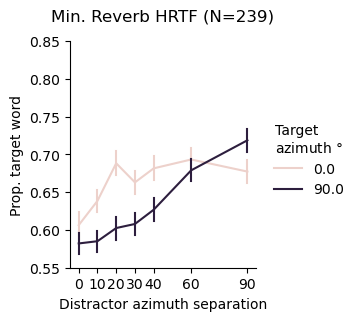

In [16]:
# get trial data excluding catch trials 

to_analyze_df = analysis_df.copy() 
to_analyze_df["target_azim"] = to_analyze_df.target_azim.abs()
to_analyze_df["dist_azim_delta"] = to_analyze_df.dist_azim_delta.abs()

part_summary_df = (to_analyze_df.groupby(["target_azim", "dist_azim_delta", "id_subject"])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())


# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]

## Compare performance based on mean accuracy allowed per participant


# to_plot['target_azim'] = to_plot['target_azim'].abs().astype(int)
g = sns.relplot(data=part_summary_df,
            kind='line',
            x='dist_azim_delta',
            y='adjusted_accuracy_mean',
            hue='target_azim',
            errorbar=('se', 1),
            err_style='bars',
            height=3, aspect=1,
           )
g.set_axis_labels("Distractor azimuth separation", "Prop. target word")

# plt.ylim(0.4,1)
# set xticks to be unique dist_azim_delta values 
g.set(xticks=part_summary_df.dist_azim_delta.unique(), yticks=np.arange(0.55, 0.86, 0.05));
# change legend title and set text aiignment to center
g._legend.set_title("Target\nazimuth $\degree$")
N = part_summary_df.id_subject.nunique()

plt.title(f"Min. Reverb HRTF (N={N})", y=1.05)




### Get model data and plot together

In [21]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
output_paths = list(Path(f"binaural_eval/simulate_2024_human_azimuth_spotlight_experiment_human_stim/").glob("*/*.csv"))
stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl')

word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

model_name_dict = {
                   'word_task_v08_control_no_attn': 'Baseline CNN',
                   "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout": "Feature-gain Model"
                  }


gend_map = {True:'same', False:'diff'}
for path in output_paths:
    
    if not any(name in str(path) for name in model_name_dict.keys()):# 'word_task_half_co_loc_v08']):
        continue

    # res_dict = pickle.load(open(path, 'rb'))
    try:
        df = pd.read_csv(path)
        df = pd.merge(df,
                            manifests[cols_to_merge],
                                        left_on='stim_name', right_on='stim_name', how='left')
        df['response'] = df['pred_word_int'].replace(ix_to_word)
        # df['confusions'] = (df.response == df.distractor_word).astype('int')
        # df['accuracy'] = (df.response == df.word).astype('int')


        # add adjusted accuracy and confusions 
        pred_words = df.response.values
        target_words = df.word.values
        target_transcripts = df.target_transcripts.values
        distractor_words = df.distractor_word.values
        distractor_transcripts = df.distractor_transcripts.values


        adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                                    if not isinstance(target_transcript, float) else np.nan
                                    for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                                    ])

        adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == dist_word)
                                    if not (isinstance(distractor_transcript, float)) else np.nan
                                    for pred_word, dist_word, distractor_transcript in zip(pred_words, distractor_words,  distractor_transcripts)
                                    ])

        df['accuracy'] = adjusted_acc
        df['confusions'] = adjusted_confs

        df['target_azim'] = int(re.search('target_azim_(-?\d+)', path.stem).group(0).strip('target_azim_'))
        df['distractor_azim'] = int(re.search('distractor_azim_(-?\d+)', path.stem).group(0).strip('distractor_azim_'))
        df['target_azim'] = df['target_azim'].apply(remap_azim)
        df['distractor_azim'] = df['distractor_azim'].apply(remap_azim)
        
        
        # df.rename(columns={"results": "accuracy"}, inplace=True)
        df['model'] = model_name_dict[path.stem.split('_target')[0]]
        results_dfs.append(df)
    except Exception as e:
        print(e)
        print(path)
        continue


results = pd.concat(results_dfs)


In [22]:
# grouped_model_results = results.groupby(['model', 'target_azim', 'distractor_azim','sex_cond', 'snr', ]).agg({'accuracy':['mean', 'sem'],
#                                                                                                                      'confusions':['mean', 'sem']}).reset_index()
# # flatten multiindex
# grouped_model_results.columns = ['_'.join(col).strip() for col in grouped_model_results.columns.values]
# # remove trailing underscore
# grouped_model_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_model_results.columns.values]

# grouped_model_results['dist_azim_delta'] = grouped_model_results['distractor_azim'] - grouped_model_results['target_azim']
# grouped_model_results.head()

In [23]:
## Add distractor azim delta to model results 
results['dist_azim_delta'] = results['distractor_azim'] - results['target_azim']


In [24]:
results.columns

Index(['pred_word_int', 'true_word_int', 'accuracy', 'stim_name', 'word',
       'target_transcripts', 'distractor_transcripts', 'distractor_word',
       'response', 'confusions', 'target_azim', 'distractor_azim', 'model',
       'dist_azim_delta'],
      dtype='object')

In [25]:
### Combine human and model dataframes 
participant_names = part_summary_df.id_subject.unique()
# valid_participants = participant_names[part_summary_df.groupby('id_subject').adjusted_accuracy_mean.mean() >= 0.5 ]

# human_to_combine = part_summary_df[part_summary_df.id_subject.isin(valid_participants)].copy()
human_to_combine = part_summary_df.copy()
human_to_combine.columns = ['target_azim', 'dist_azim_delta', 'id_subject', 'correct_mean', 'correct_count', 'confs_mean', 'accuracy', 'confusions']
N = human_to_combine.id_subject.nunique()
human_to_combine['group'] = f"Humans (N={N})"
results['group'] = results['model']

combined_df = pd.concat([human_to_combine, results], axis=0)
combined_df.head()

,target_azim,dist_azim_delta,id_subject,correct_mean,correct_count,confs_mean,accuracy,confusions,group,pred_word_int,true_word_int,stim_name,word,target_transcripts,distractor_transcripts,distractor_word,response,distractor_azim,model
0,0.0,0.0,5422ae1afdf99b328c91b203,1.00,4.0,0.00,1.00,0.00,Humans (N=239),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,0.0,558bb476fdf99b21155f2dbf,0.50,4.0,0.25,0.50,0.25,Humans (N=239),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,0.0,55a75835fdf99b26395fae40,0.75,4.0,0.00,0.75,0.00,Humans (N=239),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,0.0,55e356dac70c7a00052a57ec,0.50,4.0,0.00,0.50,0.25,Humans (N=239),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,0.0,56259489ed6e5a0005c80fde,0.50,4.0,0.00,0.50,0.00,Humans (N=239),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Poster figure 

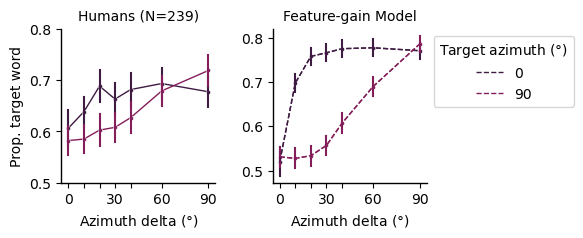

In [35]:
to_plot = combined_df.copy()
to_plot['dist_azim_delta'] = to_plot['dist_azim_delta'].abs()
to_plot['target_azim'] = to_plot['target_azim'].abs().astype(int)
models = [f'Humans (N={N})', 'Feature-gain Model']

# to_plot = to_plot[to_plot.dist_azim_delta.isin([0, 20,  40,  90])]
fontsize=10
tick_fontsize = 10
# fontsize = 10

aspect = 2
fig, axs = plt.subplots(1, 2, figsize=((aspect) * 2.5 , aspect ))

err_band_alpha = 0.4

cmap = sns.color_palette('rocket', n_colors=5)
palette = {target_azim: cmap[i] for i, target_azim in enumerate([0, 90])}

xticks = to_plot.dist_azim_delta.unique()
x_tick_labels = [0, '', '', 30, '', 60, 90]
yticks = np.arange(0.5, 0.86, 0.1)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    sns.lineplot(data=to_plot[to_plot.group == model],
                    x='dist_azim_delta',
                    y='accuracy',
                    hue='target_azim',
                    palette=palette,
                    ax=ax,
                    errorbar=('se', 2), err_style='bars',# err_kws={'alpha':err_band_alpha},
                    marker='.', 
                    )
    ax.set_xlabel("Azimuth delta ($\degree$)", fontsize=fontsize)
    ax.set_title(model, fontsize=fontsize)
    ax.set_yticks(yticks)
    ax.set_xticks(xticks)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if model == 'Feature-gain Model':
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

sns.despine()
# turn off axs[0] legend 
axs[0].legend().remove()
axs[0].set_ylabel("Prop. target word", fontsize=fontsize)
axs[1].set_ylabel("", fontsize=fontsize)
axs[1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize,title='Target azimuth ($\degree$)')
# plt.savefig(outfig_dest/'azim_spotlight_effect.pdf', transparent=True, bbox_inches='tight')



___
## Older figures 

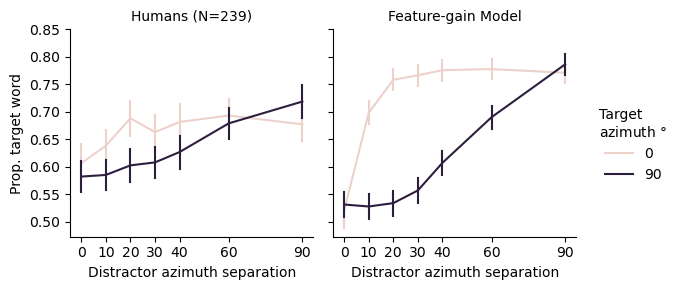

In [23]:
to_plot = combined_df.copy()
to_plot['dist_azim_delta'] = to_plot['dist_azim_delta'].abs()
to_plot['target_azim'] = to_plot['target_azim'].abs().astype(int)
g = sns.relplot(data=to_plot,
            x='dist_azim_delta',
            y='accuracy',
            hue='target_azim',
            errorbar=('se', 2),
            err_style='bars',
            col='group',
            height=3, aspect=1,
            kind='line')
g.set_titles("{col_name}")
g.set_axis_labels("Distractor azimuth separation", "Prop. target word")
# plt.ylim(0.4,1)
# set xticks to be unique dist_azim_delta values 
g.set(xticks=to_plot.dist_azim_delta.unique(), yticks=np.arange(0.5, 0.86, 0.05));
# change xtick fontsize 

# change legend title and set text aiignment to center
g._legend.set_title("Target\nazimuth $\degree$")


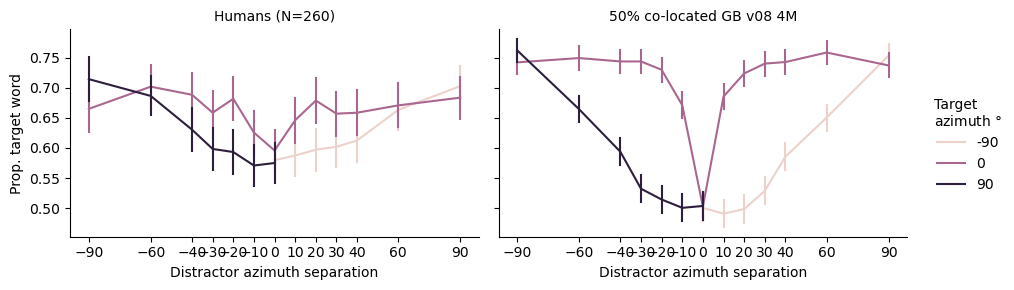

In [24]:
to_plot = combined_df.copy()
# to_plot['dist_azim_delta'] = to_plot['dist_azim_delta'].abs()
to_plot['target_azim'] = to_plot['target_azim'].astype(int)
g = sns.relplot(data=to_plot,
            x='dist_azim_delta',
            y='accuracy',
            hue='target_azim',
            errorbar=('se', 2),
            err_style='bars',
            col='group',
            height=3, aspect=1.55,
            kind='line')
g.set_titles("{col_name}")
g.set_axis_labels("Distractor azimuth separation", "Prop. target word")
# plt.ylim(0.4,1)
# set xticks to be unique dist_azim_delta values 
g.set(xticks=to_plot.dist_azim_delta.unique())
# change xtick fontsize 

# change legend title and set text aiignment to center
g._legend.set_title("Target\nazimuth $\degree$")
